<a href="https://colab.research.google.com/github/morozovsolncev/gravitation/blob/main/higgs_8_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

МОДЕЛИРОВАНИЕ ВКЛЮЧЕНИЯ ПОЛЯ ХИГГСА
Параметры: V = 0.5
     m |   ω_R (числ) |   ω_R (теор) |      Разница
--------------------------------------------------
  0.00 |     1.000140 |     1.000000 |     0.000140
  0.10 |     1.019369 |     1.019804 |    -0.000434
  0.20 |     1.076799 |     1.077033 |    -0.000234
  0.50 |     1.414424 |     1.414214 |     0.000211
  1.00 |     2.235388 |     2.236068 |    -0.000680
  1.50 |     3.161427 |     3.162278 |    -0.000850
  2.00 |     4.122421 |     4.123106 |    -0.000684


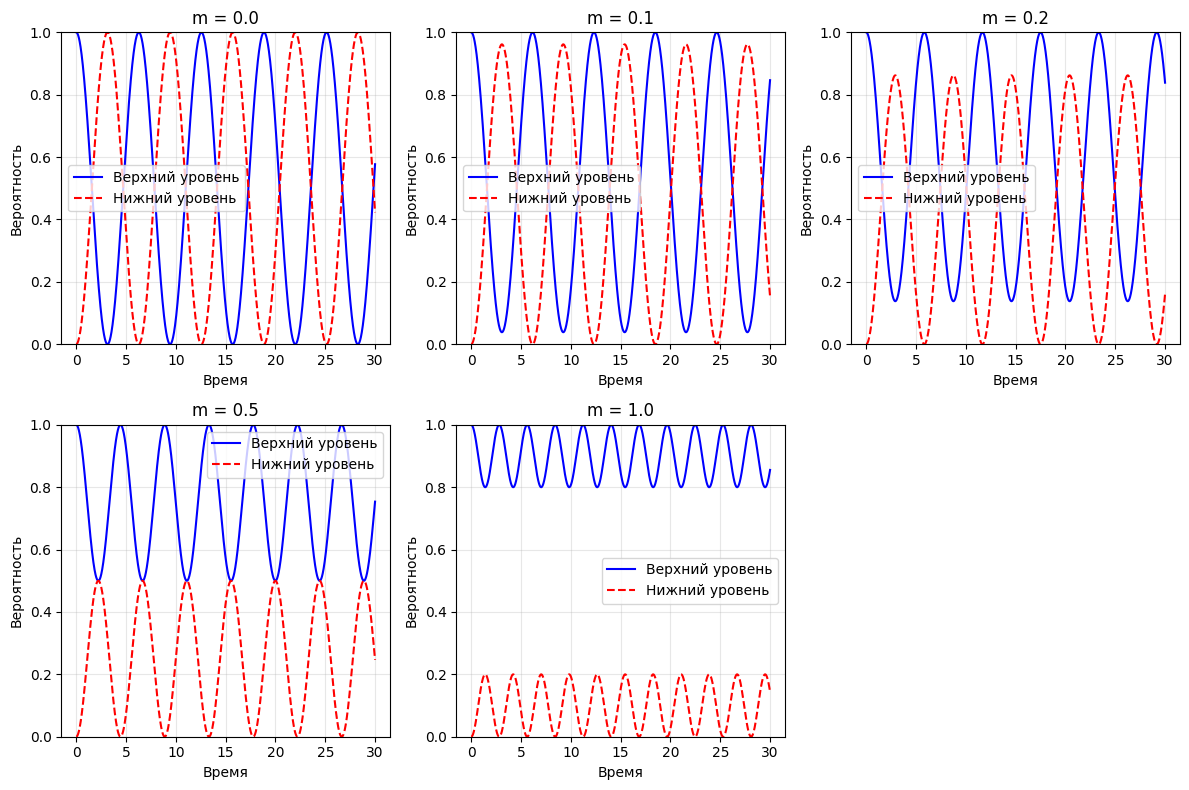

In [ ]:
"""
Численное моделирование «включения» поля Хиггса в двухуровневой системе.
Параметр m имитирует массу частицы (константу Юкавы, умноженную на v).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

def run_simulation(V, m, t_max=50, n_points=2000):
    """Решает уравнение Шрёдингера для двухуровневой системы."""
    H = np.array([[m, V], [V, -m]], dtype=complex)
    t_eval = np.linspace(0, t_max, n_points)

    def schrodinger(t, psi):
        return -1j * H @ psi

    psi0 = np.array([1.0+0j, 0.0+0j])  # начальное состояние |1>
    sol = solve_ivp(schrodinger, (0, t_max), psi0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-12)

    P_up = np.abs(sol.y[0])**2
    P_down = np.abs(sol.y[1])**2

    # Частота осцилляций
    peaks, _ = find_peaks(P_up)
    if len(peaks) > 5:
        T = np.mean(np.diff(t_eval[peaks]))
        omega = 2 * np.pi / T
    else:
        omega = 2 * np.sqrt(V**2 + m**2)

    return t_eval, P_up, P_down, omega

# Параметры
V = 0.5
m_values = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0]

print("=" * 70)
print("МОДЕЛИРОВАНИЕ ВКЛЮЧЕНИЯ ПОЛЯ ХИГГСА")
print(f"Параметры: V = {V}")
print("=" * 70)
print(f"{'m':>6} | {'ω_R (числ)':>12} | {'ω_R (теор)':>12} | {'Разница':>12}")
print("-" * 50)

for m in m_values:
    t, P_up, P_down, omega_num = run_simulation(V, m)
    omega_theor = 2 * np.sqrt(V**2 + m**2)
    diff = omega_num - omega_theor
    print(f"{m:6.2f} | {omega_num:12.6f} | {omega_theor:12.6f} | {diff:12.6f}")

print("=" * 70)

# Визуализация
plt.figure(figsize=(12, 8))
for i, m in enumerate(m_values[:5]):
    t, P_up, P_down, _ = run_simulation(V, m, t_max=30)
    plt.subplot(2, 3, i+1)
    plt.plot(t, P_up, 'b-', label='Верхний уровень')
    plt.plot(t, P_down, 'r--', label='Нижний уровень')
    plt.xlabel('Время')
    plt.ylabel('Вероятность')
    plt.title(f'm = {m}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()